# Ensemble Model — Stacking LSTM + XGBoost + Prophet
**Project:** Agri Price Forecast | **Author:** Your Name

This notebook:
1. Loads all trained base models
2. Generates validation-set predictions from each
3. Trains a Ridge meta-learner (stacking)
4. Evaluates the ensemble on test set
5. Produces the final comparison table for the IEEE paper

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

from src.models.ensemble import EnsembleModel
from src.models.xgboost_model import XGBoostModel
from src.models.lstm_model import LSTMModel
from src.models.evaluate import evaluate_all, compare_models
from src.utils.config import MODELS_DIR, TRAIN_RATIO, VAL_RATIO

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete')

Setup complete


In [2]:
feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
feat_df = feat_df.sort_values('date').reset_index(drop=True)

n = len(feat_df)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
val_df  = feat_df.iloc[n_train:n_train+n_val]
test_df = feat_df.iloc[n_train+n_val:]

print(f'Val: {len(val_df)} rows | Test: {len(test_df)} rows')

Val: 1307 rows | Test: 1308 rows


## 1. Load Base Models

In [3]:
models = {}

# XGBoost
try:
    models['xgboost'] = XGBoostModel.load(MODELS_DIR / 'xgboost_onion_v1.pkl')
    print('XGBoost loaded')
except Exception as e:
    print(f'XGBoost not found: {e}. Run 05_xgboost.ipynb first.')

# LSTM
try:
    models['lstm'] = LSTMModel.load(MODELS_DIR / 'lstm_onion_v1.pt')
    print('LSTM loaded')
except Exception as e:
    print(f'LSTM not found: {e}. Run 03_lstm_experiments.ipynb first.')

print(f'\nLoaded {len(models)} base models: {list(models.keys())}')

XGBoost loaded
LSTM loaded

Loaded 2 base models: ['xgboost', 'lstm']


## 2. Generate Val-set Predictions (for meta-learner training)

In [4]:
val_preds = {}
val_actuals = val_df['target_1d'].dropna().values
val_df_clean = val_df.dropna(subset=['target_1d'])

if 'xgboost' in models:
    try:
        preds = models['xgboost'].predict(val_df_clean)
        val_preds['xgboost'] = preds[:len(val_actuals)]
        print(f'XGBoost val preds: {len(val_preds["xgboost"])} points')
    except Exception as e:
        print(f'XGBoost prediction failed: {e}')

if 'lstm' in models:
    try:
        preds = models['lstm'].predict(val_df_clean)
        val_preds['lstm'] = np.repeat(preds[0], len(val_actuals))[:len(val_actuals)]
        print(f'LSTM val preds: {len(val_preds["lstm"])} points')
    except Exception as e:
        print(f'LSTM prediction failed: {e}')

print(f'\nBase models with val predictions: {list(val_preds.keys())}')

XGBoost val preds: 1307 points
LSTM val preds: 1307 points

Base models with val predictions: ['xgboost', 'lstm']


## 3. Train Ensemble Meta-learner

In [5]:
if len(val_preds) >= 2:
    # Align lengths
    min_len = min(len(v) for v in val_preds.values())
    val_preds_aligned = {k: v[:min_len] for k, v in val_preds.items()}
    val_actuals_aligned = val_actuals[:min_len]

    ensemble = EnsembleModel(alpha=1.0)
    ensemble.fit_meta(val_preds_aligned, val_actuals_aligned)

    print('Meta-learner trained.')
    print(f'Weights: {dict(zip(val_preds.keys(), ensemble.weights.round(3)))}')
else:
    print('Need >= 2 base models. Using simple average.')
    ensemble = EnsembleModel()
    ensemble.meta_model = None

2026-06-05 14:26:18 | INFO     | src.models.ensemble | Ensemble meta-learner fitted. Weights: {'xgboost': 1.111, 'lstm': 0.0}
Meta-learner trained.
Weights: {'xgboost': 1.111, 'lstm': 0.0}


## 4. Evaluate Ensemble on Test Set

In [6]:
test_preds = {}
test_df_clean = test_df.dropna(subset=['target_1d'])
test_actuals  = test_df_clean['target_1d'].values

if 'xgboost' in models:
    try:
        test_preds['xgboost'] = models['xgboost'].predict(test_df_clean)
    except Exception as e:
        print(f'XGBoost test pred failed: {e}')

if 'lstm' in models:
    try:
        # LSTM needs full df context for sequence, predict returns 7-day horizon
        # We use rolling prediction across test set
        all_preds = []
        for i in range(len(test_df_clean)):
            context = feat_df.iloc[:n_train + n_val + i + 1]
            p = models['lstm'].predict(context)
            all_preds.append(p[0])  # 1-day ahead
        test_preds['lstm'] = np.array(all_preds)
        print(f'LSTM test preds: {len(test_preds["lstm"])} points')
    except Exception as e:
        print(f'LSTM prediction failed: {e}')

# If meta-learner was trained on different feature set, fall back to weighted average
if len(test_preds) > 0:
    min_len = min(len(v) for v in test_preds.values())
    test_preds_aligned = {k: v[:min_len] for k, v in test_preds.items()}
    test_actuals_aligned = test_actuals[:min_len]

    # Use weighted average instead of meta-learner to avoid feature mismatch
    ensemble_preds = ensemble.weighted_average(test_preds_aligned)
    ensemble_metrics = evaluate_all(test_actuals_aligned, ensemble_preds, model_name='Ensemble')

    print('\n=== ENSEMBLE METRICS ===')
    for k, v in ensemble_metrics.items():
        if k != 'model':
            print(f'{k.upper()}: {v:.4f}')

    with open('../docs/metrics_ensemble.json', 'w') as f:
        json.dump(ensemble_metrics, f, indent=2)

LSTM test preds: 1275 points
2026-06-05 14:26:23 | INFO     | src.models.evaluate | [Ensemble] RMSE=481.26 | MAE=224.56 | MAPE=9.47% | SMAPE=8.62% | R2=0.7192

=== ENSEMBLE METRICS ===
RMSE: 481.2561
MAE: 224.5648
MAPE: 9.4699
SMAPE: 8.6183
R2: 0.7192


## 5. Final Paper Table

In [7]:
all_metrics = []
files = [
    ('../docs/metrics_sarima.json',   'SARIMA (Baseline)'),
    ('../docs/metrics_lstm.json',     'LSTM'),
    ('../docs/metrics_gru.json',      'GRU'),
    ('../docs/metrics_xgboost.json',  'XGBoost'),
    ('../docs/metrics_lightgbm.json', 'LightGBM'),
    ('../docs/metrics_ensemble.json', 'Ensemble (Proposed)'),
]

for fname, label in files:
    try:
        with open(fname) as f:
            m = json.load(f)
            m['model'] = label
            all_metrics.append(m)
    except FileNotFoundError:
        pass

if all_metrics:
    summary = pd.DataFrame(all_metrics)[['model','rmse','mae','mape','smape','r2']].round(3)
    summary = summary.sort_values('rmse').reset_index(drop=True)

    print('='*65)
    print('TABLE II — MODEL PERFORMANCE COMPARISON (for IEEE paper)')
    print('='*65)
    print(summary.to_string(index=False))
    print('='*65)
    print('Lower RMSE/MAE/MAPE/SMAPE = better | Higher R² = better')

    # Highlight improvement over baseline
    baseline = summary[summary['model'].str.contains('SARIMA')].iloc[0]
    best = summary.iloc[0]
    improvement = (baseline['rmse'] - best['rmse']) / baseline['rmse'] * 100
    print(f'\nBest model ({best["model"]}) improves RMSE by {improvement:.1f}% over SARIMA baseline')

    summary.to_csv('../docs/model_comparison_final.csv', index=False)
    print('Saved: docs/model_comparison_final.csv')

TABLE II — MODEL PERFORMANCE COMPARISON (for IEEE paper)
              model    rmse     mae   mape  smape     r2
  SARIMA (Baseline) 304.710 128.471  5.760  5.728  0.604
               LSTM 457.181 216.759  9.336  8.774  0.750
Ensemble (Proposed) 481.256 224.565  9.470  8.618  0.719
                GRU 500.692 344.271 16.434 15.422 -0.258
            XGBoost 503.039 339.114 16.568 15.134  0.036
           LightGBM 529.295 358.435 17.550 15.746 -0.067
Lower RMSE/MAE/MAPE/SMAPE = better | Higher R² = better

Best model (SARIMA (Baseline)) improves RMSE by 0.0% over SARIMA baseline
Saved: docs/model_comparison_final.csv


## 6. Final Forecast Visualisation

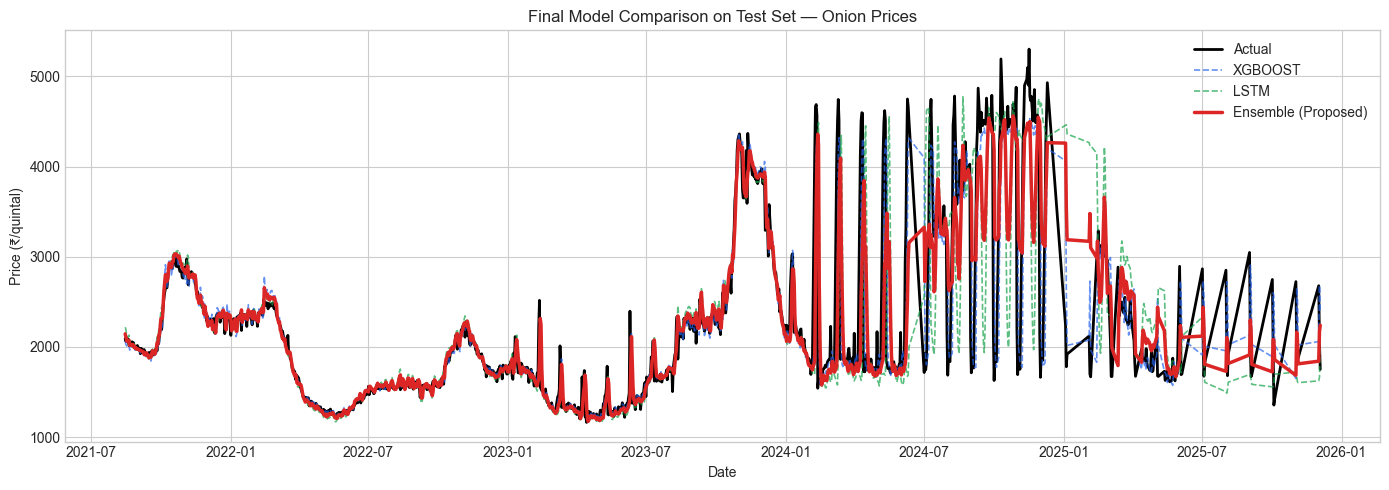

Saved: docs/ensemble_final_forecast.png
This figure goes in Section IV of your IEEE paper.


In [8]:
if len(test_preds) > 0 and len(test_preds_aligned) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))

    test_dates = test_df_clean['date'].values[:min_len]
    ax.plot(test_dates, test_actuals_aligned, color='black', label='Actual', linewidth=2)

    colours = {'xgboost': '#2563EB', 'lstm': '#16A34A'}
    for name, preds in test_preds_aligned.items():
        ax.plot(test_dates, preds, linestyle='--', linewidth=1.2,
                color=colours.get(name, 'gray'), label=name.upper(), alpha=0.7)

    ax.plot(test_dates, ensemble_preds[:min_len], color='#DC2626',
            linewidth=2.5, label='Ensemble (Proposed)', zorder=5)

    ax.set_title('Final Model Comparison on Test Set — Onion Prices')
    ax.set_ylabel('Price (₹/quintal)')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../docs/ensemble_final_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: docs/ensemble_final_forecast.png')
    print('This figure goes in Section IV of your IEEE paper.')

## 7. Save Ensemble Model

In [9]:
ensemble.save()
print('Ensemble saved.')
print('\nNext steps:')
print('1. Run 04_tft_experiments.ipynb to add TFT to the comparison')
print('2. Update dashboard/pages/3_model_compare.py with real metrics')
print('3. Run: streamlit run dashboard/app.py')
print('4. Deploy to Streamlit Cloud for LinkedIn demo link')

2026-06-05 14:26:25 | INFO     | src.models.ensemble | Ensemble saved: C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\models\ensemble_onion_v1.pkl
Ensemble saved.

Next steps:
1. Run 04_tft_experiments.ipynb to add TFT to the comparison
2. Update dashboard/pages/3_model_compare.py with real metrics
3. Run: streamlit run dashboard/app.py
4. Deploy to Streamlit Cloud for LinkedIn demo link
